## Problem 1
***
#### a.

In [1]:
import re
def geo_valid_set(test_case):
    Lat_part = r'^-?(([1-8]\d|\d)(\.\d{1,3})?|90(\.0{1,3})?)'
    Long_part = r'-?((1[0-7]\d|[1-9]\d|\d)(\.\d{1,3})?|180(\.0{1,3})?)$'
    re_form = re.compile(Lat_part + r',\s?' + Long_part)
    valid_set = [od for od in test_case if re_form.match(od)]
    return valid_set

#### b.

In [2]:
test_case = ["45,180",
             "-90,-127.4321",
             "90.1,10",
             "045,90",
             "0.0,0.0",
             "45,90."]
geo_valid_set(test_case)

['45,180', '0.0,0.0']

## Problem 2
***
#### a.

In [3]:
import numpy as np
np.set_printoptions(precision = 5,suppress = True)
# Define the non-normalizing density
f = np.vectorize(lambda x:np.exp(-x/2) * (1 + np.cos(x)**2))
# Simpson Rule
def Simp_R(f,a,b,n):
    if n % 2 != 0:
        raise ValueError
    h = (b - a) / n
    fk = f(np.linspace(a,b,n+1))
    wk = np.hstack([np.array([1,4]),
                    np.tile([2,4],int(n/2)-1),
                    np.array([1])])
    return np.inner(fk,wk) * (h / 3)
# Normalized constant
n = 1000
a,b = 0,2*np.pi
nC = Simp_R(f,a,b,n)
print(f'C is {nC}')

C is 2.926639779405679


#### b.

In [4]:
from scipy.optimize import minimize
obj = lambda x:(-f(x) / nC)
Mp = -minimize(obj,0.5).fun * 2 * np.pi
print(f'Mp = {Mp}')

Mp = 4.8815044241822525


#### c.

In [5]:
runs = 10000
accepts = []
target = lambda x:f(x) / nC * (x > 0) * (x < 2*np.pi)
proposal = lambda x: 1 / (2 *np.pi) * (x > 0) * (x < 2*np.pi)
for _ in range(runs):
    uk = np.random.uniform(0,1,1)
    yk = np.random.uniform(0,2*np.pi,1)
    if uk <= target(yk) / (proposal(yk)*Mp):
        accepts.append(yk[0])

#### d.

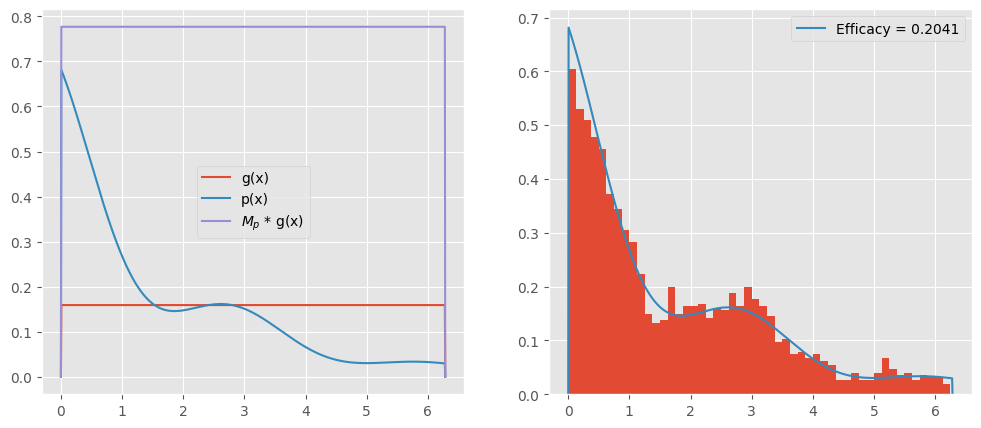

In [6]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
# Visual the Result
Xg = np.linspace(a,b,n+1)
plt.figure(figsize = [12,5])
plt.subplot(1,2,1)
plt.plot(Xg,proposal(Xg),label = 'g(x)')
plt.plot(Xg,target(Xg),label = 'p(x)')
plt.plot(Xg,Mp * proposal(Xg),label = '$M_p$ * g(x)')
plt.legend()
plt.subplot(1,2,2)
plt.hist(accepts,density = True,bins = 50)
plt.plot(Xg,target(Xg),label = f'Efficacy = {len(accepts) / runs}')
plt.legend()

## Problem 3
***
#### a.

In [7]:
def GS_norm(Xv):
    wL = [Xv[0] / np.linalg.norm(Xv[0])]
    for xk in Xv[1:]:
        vk = xk.astype(float)
        for wk in wL:
            vk -= np.dot(xk,wk) * wk
        wk = vk / np.linalg.norm(vk)
        wL.append(wk)
    return wL

#### b.

In [8]:
Xv = [np.array([1,0,1,0]), # x1
      np.array([1,1,1,1]), # x2
      np.array([-1,2,0,1])] # x3
Ov = GS_norm(Xv)
display(np.array(Ov))
# Orthogonality and Normality check
display(np.array(Ov) @ np.array(Ov).T)

array([[ 0.70711,  0.     ,  0.70711,  0.     ],
       [ 0.     ,  0.70711,  0.     ,  0.70711],
       [-0.5    ,  0.5    ,  0.5    , -0.5    ]])

array([[ 1.,  0., -0.],
       [ 0.,  1.,  0.],
       [-0.,  0.,  1.]])

## Problem 4
***
#### a.

In [9]:
def back_sub(b,R):
    n = len(b)
    beta = np.zeros(n)
    for i in range(n):
        k = (n - 1) - i
        negT = sum([R[k,j]*beta[j] for j in range(k+1,n)])
        beta[k] = (b[k,0] - negT) / R[k,k]
    return beta

#### b.

In [10]:
# Input Data
vec1 = np.ones((12,1))
X1 = np.array([[0,2,2,2,4,4,4,6,6,6,8,8]]).T
X2 = np.array([[2,6,7,5,9,8,7,10,11,9,15,13]]).T
Xm = np.hstack([vec1,X1,X2])
y = np.array([[2,3,2,7,6,8,10,7,8,12,11,14]]).T
# QR decomposition
Q,R = np.linalg.qr(Xm)
b = Q.T @ y
# Back substitution algorithm
np.round(back_sub(b,R),decimals = 3)

array([ 5.375,  3.012, -1.285])